<h2>Лабораторна робота №7</h2>
<h3>Знаходження мінімуму та максимуму функцій за допомогою генетичних алгоритмів</h3>

--- РЕЗУЛЬТАТИ ВАРІАНТУ 5 ---
1. Мінімізація y(x): x = -1.9317, f(x) = -0.9079
2. Максимізація z(x,y): x = 12.4977, y = -10.8143, f(x,y) = 12.4185


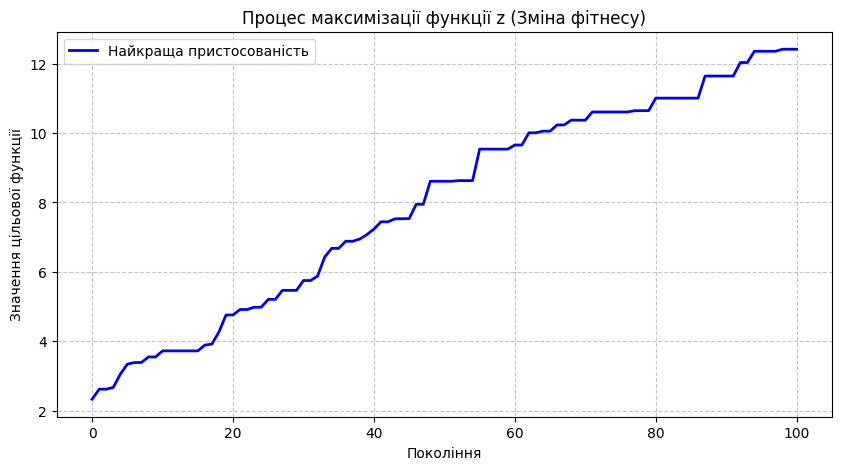

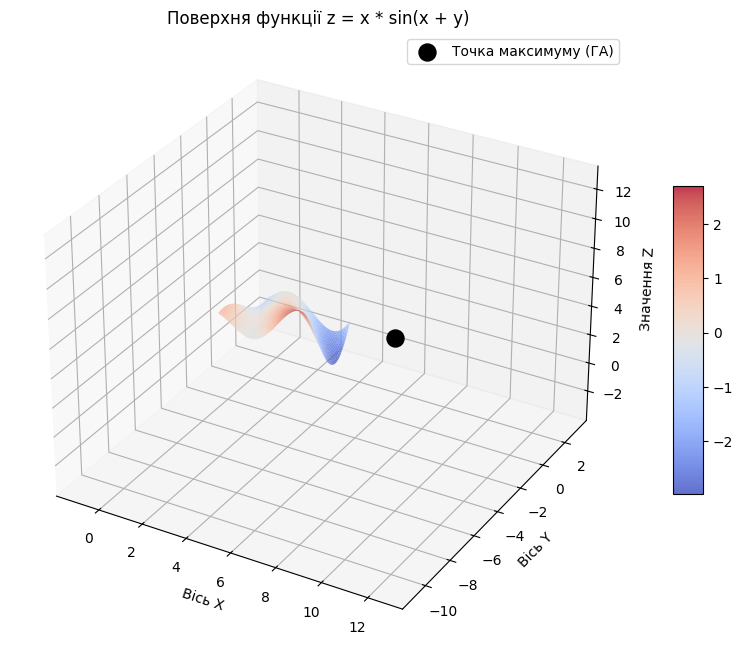

In [5]:
import pygad # Імпортується бібліотека PyGAD, яка реалізує генетичні алгоритми (відбір, мутація, кросовер тощо)
import numpy as np # Імпортується NumPy для чисельних обчислень (тригонометричні функції, масиви, вектори)
import matplotlib.pyplot as plt # Імпортується Matplotlib для побудови 2D-графіків
from mpl_toolkits.mplot3d import Axes3D # Підключається інструмент для 3D-візуалізації поверхонь функцій

import warnings # Імпортується модуль для керування попередженнями Python
warnings.filterwarnings("ignore") # Вимикаються всі попередження, щоб вони не засмічували консоль

# Варіант 5
# 1. y = sin|x| * cos(3x/2) -> Мінімізація
# 2. z = x * sin(x + y)    -> Максимізація

# ЗАВДАННЯ 1: Мінімізація функції однієї змінної

# Оголошується функція function_y, яка приймає один аргумент x
# Обчислюється значення функції: Варіант 5: y = sin|x| * cos(3x/2)
def function_y(x):
    return np.sin(np.abs(x)) * np.cos(3 * x / 2)

# Оголошується fitness-функція для генетичного алгоритму: ga_instance — екземпляр алгоритму,
# solution — поточне рішення (хромосома), solution_idx — індекс рішення
def fitness_func_y(ga_instance, solution, solution_idx):
# Оскільки розв’язується задача з однією змінною, беремо перший ген як x
    x = solution[0]
# Оскільки PyGAD максимізує, повертаємо від'ємне значення для мінімізації
# Повертається від’ємне значення функції, перетворюючи максимізацію на мінімізацію
    return -function_y(x) 

# Створюється об’єкт генетичного алгоритму для задачі мінімізації
# Кількість поколінь (ітерацій еволюції): num_generations=100,
# Кількість батьків, які беруть участь у схрещуванні: num_parents_mating=5,
# Вказується fitness-функція: fitness_func=fitness_func_y,
# Кількість рішень у кожній популяції: sol_per_pop=10,
# Кількість генів у хромосомі (1 змінна — x): num_genes=1,
# Діапазон початкових значень x: init_range_low=-4, init_range_high=1,
# Відсоток генів, які випадково мутують: mutation_percent_genes=10,
# Зберігаються найкращі рішення кожного покоління:  save_best_solutions=True
ga_y = pygad.GA(num_generations=100,
                num_parents_mating=5,
                fitness_func=fitness_func_y,
                sol_per_pop=10,
                num_genes=1,
                init_range_low=-4,
                init_range_high=1,
                mutation_percent_genes=10,
                save_best_solutions=True)

# Запуск генетичного алгоритму: 
ga_y.run()

# ЗАВДАННЯ 2: Максимізація функції двох змінних

# Оголошується функція двох змінних
# Обчислюється: z(x,y)=x⋅sin(x+y)
def function_z(x, y):
    return x * np.sin(x + y)

# Оголошується Fitness-функція для задачі максимізації
def fitness_func_z(ga_instance, solution, solution_idx):
# З хромосоми витягуються два гени: x і y
    x, y = solution
# Повертається значення функції (максимізація без інверсії)
    return function_z(x, y)

# Створюється другий генетичний алгоритм
# Кількість поколінь (ітерацій еволюції): num_generations=100,
# Кількість батьків, які беруть участь у схрещуванні: num_parents_mating=5,
# Вказується fitness-функція: fitness_func=fitness_func_z,
# Кількість рішень у кожній популяції: sol_per_pop=10,
# Кількість генів у хромосомі (Два гени — x і y): num_genes=2,
# Початковий діапазон змінних: init_range_low=-1,init_range_high=3,
# Відсоток генів, які випадково мутують: mutation_percent_genes=10,
# Зберігаються найкращі рішення кожного покоління:  save_best_solutions=True
ga_z = pygad.GA(num_generations=100,
                num_parents_mating=5,
                fitness_func=fitness_func_z,
                sol_per_pop=10,
                num_genes=2,
                init_range_low=-1,
                init_range_high=3,
                mutation_percent_genes=10,
                save_best_solutions=True)

# Запуск генетичного алгоритму: 
ga_z.run()

# Вивід результатів у консоль
sol_y, fit_y, _ = ga_y.best_solution() # Отримується найкраще рішення для задачі 1
sol_z, fit_z, _ = ga_z.best_solution() # Отримується найкраще рішення для задачі 2

print(f"--- РЕЗУЛЬТАТИ ВАРІАНТУ 5 ---") # Вивід заголовка
# Виводиться знайдене мінімальне значення функції
print(f"1. Мінімізація y(x): x = {sol_y[0]:.4f}, f(x) = {function_y(sol_y[0]):.4f}")
# Виводиться точка максимуму функції двох змінних
print(f"2. Максимізація z(x,y): x = {sol_z[0]:.4f}, y = {sol_z[1]:.4f}, f(x,y) = {fit_z:.4f}")

# ГРАФІЧНИЙ АНАЛІЗ
# 1. Графік пристосованості для Завдання 2
plt.figure(figsize=(10, 5)) # Створюється вікно графіка
# Використовуємо список значень фітнесу напряму з об'єкта GA
# Будується графік зміни найкращого значення fitness по поколіннях
plt.plot(ga_z.best_solutions_fitness, label="Найкраща пристосованість", color='blue', linewidth=2)
plt.title("Процес максимізації функції z (Зміна фітнесу)") # Надається назву графіку
plt.xlabel("Покоління") # Підпис осі X
plt.ylabel("Значення цільової функції") # Підпис осі Y
# Відображається маленьке віконце на графіку, де написано, що означають лінії на графіку
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7) # Вмикається відображення сітки на графіку
plt.show() # Зображується графік

# 2. 3D Поверхня функції z
x_range = np.linspace(-1, 3, 100) # Створюються діапазони значень x 
y_range = np.linspace(-1, 3, 100) # Створюються діапазони значень y
X, Y = np.meshgrid(x_range, y_range) # Формується координатна сітка
Z = function_z(X, Y) # Обчислюється значення функції в кожній точці сітки

fig = plt.figure(figsize=(12, 8)) # Створюється додаткове вікно для 3D-графіка
ax = fig.add_subplot(111, projection='3d') # Створюється 3D-графік
surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.8, edgecolor='none') # Будується поверхня функції
# Додаємо точку знайденого максимуму
# Відмічається точка максимуму, знайдена генетичним алгоритмом
ax.scatter(sol_z[0], sol_z[1], fit_z, color='black', s=150, label='Точка максимуму (ГА)')
ax.set_title("Поверхня функції z = x * sin(x + y)") # Надається назву графіку
ax.set_xlabel("Вісь X") # Підпис осі X
ax.set_ylabel("Вісь Y") # Підпис осі Y
ax.set_zlabel("Значення Z") # Підпис осі Z
plt.colorbar(surf, shrink=0.5, aspect=10) # Додається шкала кольорів
# Відображається маленьке віконце на графіку, де написано, що означають лінії на графіку
plt.legend()
plt.show() # Зображується графік

# ==============================================================================
# КОНТРОЛЬНІ ЗАПИТАННЯ:
# ==============================================================================
# 1. Генетичний алгоритм (ГА) — це евристичний алгоритм пошуку, що базується на ідеях природного відбору та генетики (спадковість, мутації, виживання найсильніших).
# 2. Етапи: створення початкової популяції, розрахунок пристосованості, селекція (відбір), рекомбінація (кросовер), мутація, перехід до наступного покоління.
# 3. Популяція — сукупність хромосом (осіб), кожна з яких є потенційним розв'язком.
# 4. Функція пристосованості оцінює якість кожного розв'язку. Алгоритм прагне знайти хромосому з найвищим її значенням.
# 5. Відбір (selection) — процес вибору найбільш "сильних" особин для створення потомства, що забезпечує передачу корисних ознак.
# 6. Кросовер — основний оператор ГА, який поєднує гени двох батьків, дозволяючи досліджувати нові області простору пошуку.
# 7. Типи кросоверу: одноточковий, багатоточковий, рівномірний.
# 8. Мутація — випадкова зміна генів, що дозволяє алгоритму уникати локальних екстремумів та зберігати генетичну різноманітність.
# 9. Різноманітність підтримується за допомогою мутацій та регулювання розміру популяції.
# 10. Критерії зупинки: виконання заданої кількості поколінь, досягнення певного порогу точності або відсутність прогресу протягом кількох етапів.
# 11. Застосовуються в задачах багатопараметричної оптимізації, де класичні методи (градієнтні) неефективні.
# 12. Переваги: не потребують неперервності або диференційованості функції, добре працюють у складних ландшафтах.
# 13. Недоліки: великі обчислювальні витрати, чутливість до налаштування параметрів (ймовірність мутації тощо).
# 14. Вплив параметрів: більша популяція зменшує ризик швидкої збіжності до помилкового рішення, але потребує більше пам'яті та часу.
# 15. Сфери: проектування складних мереж, фінансова аналітика, аеродинаміка, робототехніка.
# ==============================================================================

<h2>Виконала студентка групи ЗПІ-зп41  <br>Грищенко Юлія</h2>
